<a href="https://colab.research.google.com/github/ThetPi/My-Projects/blob/main/Food_101_10___.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir


--2026-09-17 02:45:31--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-09-17 02:45:32 (65.6 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [2]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip


--2026-09-17 02:46:07--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.98.207, 74.125.135.207, 74.125.142.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G   137MB/s    in 17s     

2026-09-17 02:46:24 (92.2 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [3]:
unzip_data('101_food_classes_10_percent.zip')

walk_through_dir('101_food_classes_10_percent')

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/test'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/samosa'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/pork_chop'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/greek_salad'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/spring_rolls'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/frozen_yogurt'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/sashimi'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/chocolate_mousse'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/chicken_curry'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/garlic_bread'.
There are 0 directories and 250 images in

In [4]:
train_dir = '101_food_classes_10_percent/train/'
test_dir = '101_food_classes_10_percent/test/'

In [5]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np


In [6]:
IMG_SIZE = (224,224)
train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                            label_mode='categorical',
                                                                            image_size=IMG_SIZE)
test_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                            label_mode='categorical',
                                                                            image_size=IMG_SIZE,
                                                                           shuffle=False)

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


In [ ]:
len(train_data_10_percent.class_names)

101

In [ ]:
checkpoint_path = "101_classes_10_percent_data_model_checkpoint.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                         save_best_only=True,
                                                         save_weights_only=True,
                                                         monitor='val_accuracy')

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2)
],name='data_augmentation')


In [ ]:
INPUT_SHAPE = (224,224,3)
base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top=False)
base_model.trainable = False

inputs = layers.Input(shape=INPUT_SHAPE,name='input_layer')
x = data_augmentation(inputs)
x = base_model(x,training=False)
x = layers.GlobalAveragePooling2D(name='global_avg_pooling_layer')(x)
outputs = layers.Dense(len(train_data_10_percent.class_names),activation='softmax',name='output_layer')(x)

model = tf.keras.Model(inputs,outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pooling_layer        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

his_10_percent_aug = model.fit(train_data_10_percent,
                               epochs=5,
                               validation_data=test_data_10_percent,
                               validation_steps=int(0.15*len(test_data_10_percent)),
                               callbacks=[checkpoint_callback]
                               )

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 54s 170ms/step - accuracy: 0.2653 - loss: 3.4270 - val_accuracy: 0.5000 - val_loss: 2.3050
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 75s 155ms/step - accuracy: 0.4851 - loss: 2.2624 - val_accuracy: 0.5516 - val_loss: 1.8520
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 155ms/step - accuracy: 0.5547 - loss: 1.8954 - val_accuracy: 0.5771 - val_loss: 1.6874
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 38s 159ms/step - accuracy: 0.5894 - loss: 1.6769 - val_accuracy: 0.5882 - val_loss: 1.5945
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 161ms/step - accuracy: 0.6186 - loss: 1.5424 - val_accuracy: 0.6009 - val_loss: 1.5412


In [ ]:
results_feature_extraction_model = model.evaluate(test_data_10_percent)
results_feature_extraction_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.5842 - loss: 1.5834


[1.5833837985992432, 0.5842376351356506]

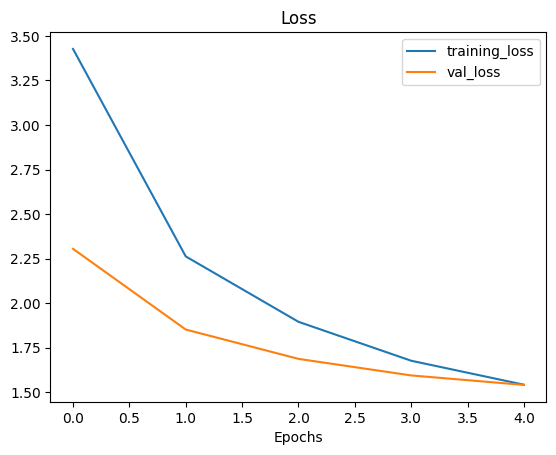

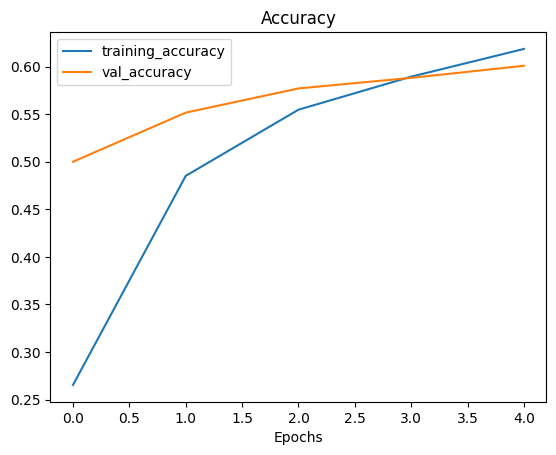

In [ ]:
plot_loss_curves(his_10_percent_aug)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-5]:
  layer.trainable = False

In [ ]:
model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=['accuracy'])

In [ ]:
for idx,layer in enumerate(base_model.layers):
  print(f'{idx} -> {layer.name} -> {layer.trainable}')

0 -> input_layer -> False
1 -> rescaling -> False
2 -> normalization -> False
3 -> rescaling_1 -> False
4 -> stem_conv_pad -> False
5 -> stem_conv -> False
6 -> stem_bn -> False
7 -> stem_activation -> False
8 -> block1a_dwconv -> False
9 -> block1a_bn -> False
10 -> block1a_activation -> False
11 -> block1a_se_squeeze -> False
12 -> block1a_se_reshape -> False
13 -> block1a_se_reduce -> False
14 -> block1a_se_expand -> False
15 -> block1a_se_excite -> False
16 -> block1a_project_conv -> False
17 -> block1a_project_bn -> False
18 -> block2a_expand_conv -> False
19 -> block2a_expand_bn -> False
20 -> block2a_expand_activation -> False
21 -> block2a_dwconv_pad -> False
22 -> block2a_dwconv -> False
23 -> block2a_bn -> False
24 -> block2a_activation -> False
25 -> block2a_se_squeeze -> False
26 -> block2a_se_reshape -> False
27 -> block2a_se_reduce -> False
28 -> block2a_se_expand -> False
29 -> block2a_se_excite -> False
30 -> block2a_project_conv -> False
31 -> block2a_project_bn -> Fal

In [ ]:
fine_tune_epochs = 10 # model has already done 5 epochs, this is the total number of epochs we're after (5+5=10)

history_all_classes_10_percent_fine_tune = model.fit(train_data_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data_10_percent,
                                                     validation_steps=int(0.15 * len(test_data_10_percent)),
                                                     initial_epoch=his_10_percent_aug.epoch[-1])

Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 51s 173ms/step - accuracy: 0.6389 - loss: 1.4669 - val_accuracy: 0.6088 - val_loss: 1.4799
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 158ms/step - accuracy: 0.6800 - loss: 1.3025 - val_accuracy: 0.6205 - val_loss: 1.4320
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 38s 160ms/step - accuracy: 0.6956 - loss: 1.2324 - val_accuracy: 0.6282 - val_loss: 1.4056
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 157ms/step - accuracy: 0.7109 - loss: 1.1696 - val_accuracy: 0.6282 - val_loss: 1.3946
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 154ms/step - accuracy: 0.7205 - loss: 1.1165 - val_accuracy: 0.6343 - val_loss: 1.3680
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 36s 152ms/step - accuracy: 0.7352 - loss: 1.0570 - val_accuracy: 0.6327 - val_loss: 1.3671


In [ ]:
fine_tune_epochs

10

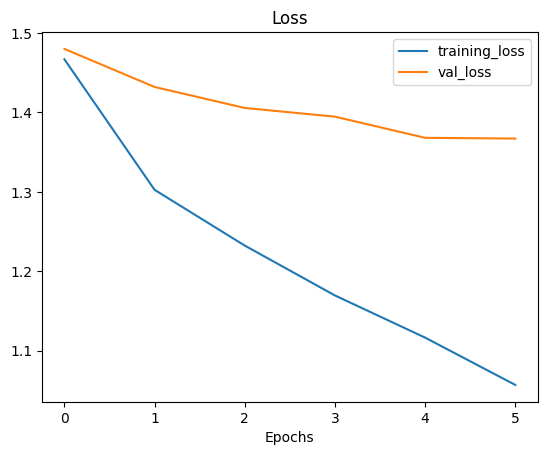

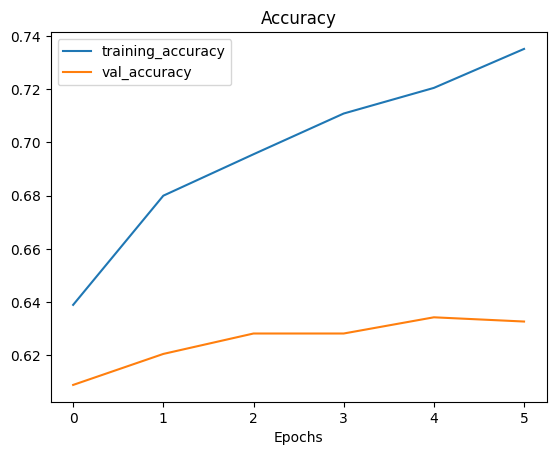

In [ ]:
plot_loss_curves(history_all_classes_10_percent_fine_tune)

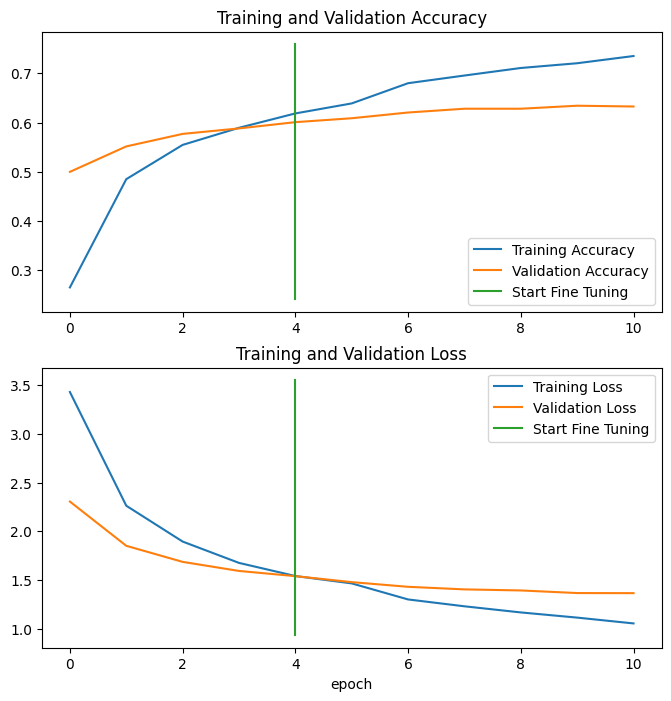

In [ ]:
compare_historys(his_10_percent_aug,history_all_classes_10_percent_fine_tune)

In [ ]:
result_of_fine_tuning = model.evaluate(test_data_10_percent)
result_of_fine_tuning

790/790 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.6208 - loss: 1.4151


[1.4150876998901367, 0.6208316683769226]

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# model.save("drive/My Drive/tensorflow_course/101_food_class_10_percent_saved_big_dog_model")
model.save('drive/MyDrive/tensorflow-course/101_food_class_10_percent_saved_big_dog_model.keras')

In [ ]:
!pwd

/content


In [8]:
model_loaded = tf.keras.models.load_model('drive/MyDrive/tensorflow-course/101_food_class_10_percent_saved_big_dog_model.keras')

In [9]:
model_loaded.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pooling_layer        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,596 (22.89 MB)

 Trainable params: 910,821 (3.47 MB)

 Non-trainable params: 3,268,131 (12.47 MB)

 Optimizer params: 1,821,644 (6.95 MB)

In [ ]:
loaded_model_result = model_loaded.evaluate(test_data_10_percent)

790/790 ━━━━━━━━━━━━━━━━━━━━ 64s 77ms/step - accuracy: 0.6208 - loss: 1.4151


In [ ]:
loaded_model_result

[1.4150875806808472, 0.6208316683769226]

In [10]:
pred_probs = model_loaded.predict(test_data_10_percent,verbose=1)

790/790 ━━━━━━━━━━━━━━━━━━━━ 71s 84ms/step


In [ ]:
pred_probs

array([[3.4405127e-01, 2.6248529e-04, 2.1816723e-01, ..., 3.1805674e-05,
        4.7352635e-03, 1.5003742e-02],
       [9.1756785e-01, 4.2678633e-07, 1.8020915e-03, ..., 2.1332798e-03,
        3.7984423e-06, 4.9115548e-05],
       [4.3542713e-01, 1.7796822e-02, 1.0628594e-02, ..., 1.1325161e-03,
        5.2507303e-04, 5.7216440e-03],
       ...,
       [1.3451063e-04, 1.1048656e-01, 9.0563817e-06, ..., 2.0924867e-03,
        5.9644319e-04, 3.5373718e-01],
       [1.3655894e-02, 1.3996217e-02, 1.4908582e-02, ..., 1.3318531e-03,
        4.7119713e-04, 1.6335070e-01],
       [3.7748311e-02, 3.9804489e-03, 8.6798761e-03, ..., 2.1713930e-03,
        6.2348013e-04, 7.1855634e-01]], dtype=float32)

In [ ]:
len(pred_probs)

25250

In [ ]:
pred_probs.shape

(25250, 101)

In [ ]:
pred_probs[10].argmax()

np.int64(0)

In [11]:
import numpy as np
pred_classes = pred_probs.argmax(axis=1)
pred_classes

array([  0,   0,   0, ..., 100,  94, 100])

In [ ]:
len(pred_classes)

25250

In [12]:
y_true = []
for img,label in test_data_10_percent.unbatch():
  y_true.append(label.numpy().argmax())
y_true[:10]

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0)]

In [ ]:
from sklearn.metrics import accuracy_score
sklearn_accuracy = accuracy_score(y_true, pred_classes)
sklearn_accuracy

0.6208316831683168

In [ ]:
# Note: The following confusion matrix code is a remix of Scikit-Learn's
# plot_confusion_matrix function - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Our function needs a different name to sklearn's plot_confusion_matrix
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15, norm=False, savefig=False):
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).
    norm: normalize values or not (default=False).
    savefig: save confusion matrix to file (default=False).

  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  ### Added: Rotate xticks for readability & increase font size (required due to such a large confusion matrix)
  plt.xticks(rotation=70, fontsize=text_size)
  plt.yticks(fontsize=text_size)

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")

In [ ]:
make_confusion_matrix(y_true=y_true,
                      y_pred=pred_classes,
                      classes=test_data_10_percent.class_names,
                      figsize=(100,100),
                      norm=False,
                      savefig=True,
                       text_size=20
                      )

In [13]:
from sklearn.metrics import classification_report
skl_classifi_report = classification_report(y_true,pred_classes)
print(skl_classifi_report)

              precision    recall  f1-score   support

           0       0.29      0.22      0.25       250
           1       0.53      0.74      0.62       250
           2       0.60      0.66      0.63       250
           3       0.76      0.59      0.66       250
           4       0.55      0.43      0.48       250
           5       0.49      0.44      0.46       250
           6       0.76      0.78      0.77       250
           7       0.84      0.78      0.81       250
           8       0.27      0.62      0.37       250
           9       0.41      0.68      0.51       250
          10       0.51      0.41      0.45       250
          11       0.77      0.67      0.71       250
          12       0.72      0.63      0.67       250
          13       0.58      0.50      0.54       250
          14       0.51      0.69      0.58       250
          15       0.43      0.44      0.43       250
          16       0.66      0.58      0.62       250
          17       0.45    

In [14]:
classification_report_dict = classification_report(y_true, pred_classes, output_dict=True)
classification_report_dict

{'0': {'precision': 0.28865979381443296,
  'recall': 0.224,
  'f1-score': 0.25225225225225223,
  'support': 250.0},
 '1': {'precision': 0.5329512893982808,
  'recall': 0.744,
  'f1-score': 0.6210350584307178,
  'support': 250.0},
 '2': {'precision': 0.6021897810218978,
  'recall': 0.66,
  'f1-score': 0.6297709923664122,
  'support': 250.0},
 '3': {'precision': 0.7551020408163265,
  'recall': 0.592,
  'f1-score': 0.6636771300448431,
  'support': 250.0},
 '4': {'precision': 0.5510204081632653,
  'recall': 0.432,
  'f1-score': 0.484304932735426,
  'support': 250.0},
 '5': {'precision': 0.4868421052631579,
  'recall': 0.444,
  'f1-score': 0.46443514644351463,
  'support': 250.0},
 '6': {'precision': 0.7626459143968871,
  'recall': 0.784,
  'f1-score': 0.7731755424063116,
  'support': 250.0},
 '7': {'precision': 0.8398268398268398,
  'recall': 0.776,
  'f1-score': 0.8066528066528067,
  'support': 250.0},
 '8': {'precision': 0.2663230240549828,
  'recall': 0.62,
  'f1-score': 0.3725961538461

In [15]:
class_names = test_data_10_percent.class_names
class_f1_score = {}

for k,v in classification_report_dict.items():
  if k == 'accuracy':
    break
  else:
    class_f1_score[class_names[int(k)]] = v['f1-score']
class_f1_score

{'apple_pie': 0.25225225225225223,
 'baby_back_ribs': 0.6210350584307178,
 'baklava': 0.6297709923664122,
 'beef_carpaccio': 0.6636771300448431,
 'beef_tartare': 0.484304932735426,
 'beet_salad': 0.46443514644351463,
 'beignets': 0.7731755424063116,
 'bibimbap': 0.8066528066528067,
 'bread_pudding': 0.37259615384615385,
 'breakfast_burrito': 0.5128205128205128,
 'bruschetta': 0.45434298440979953,
 'caesar_salad': 0.7136752136752137,
 'cannoli': 0.6723404255319149,
 'caprese_salad': 0.5373134328358209,
 'carrot_cake': 0.5830508474576271,
 'ceviche': 0.4316831683168317,
 'cheese_plate': 0.6157112526539278,
 'cheesecake': 0.4523809523809524,
 'chicken_curry': 0.5030425963488844,
 'chicken_quesadilla': 0.6750524109014675,
 'chicken_wings': 0.734225621414914,
 'chocolate_cake': 0.5761316872427984,
 'chocolate_mousse': 0.39790575916230364,
 'churros': 0.7463917525773196,
 'clam_chowder': 0.732943469785575,
 'club_sandwich': 0.7246963562753036,
 'crab_cakes': 0.4385245901639344,
 'creme_brule

In [16]:
import pandas as pd

f1_scores = pd.DataFrame({'Class Name':list(class_f1_score.keys()),
                         'F1 Score':list(class_f1_score.values())}).sort_values('F1 Score',ascending=False)
f1_scores.head()

,Class Name,F1 Score
33,edamame,0.970414
63,macarons,0.865342
75,pho,0.853282
54,hot_and_sour_soup,0.846307
69,oysters,0.844000


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=f1_score)

https://docs.google.com/spreadsheets/d/1_jg6SB8evgaEn13ezY9N8csP7yRJRSwGvQewATXb5ic/edit#gid=0


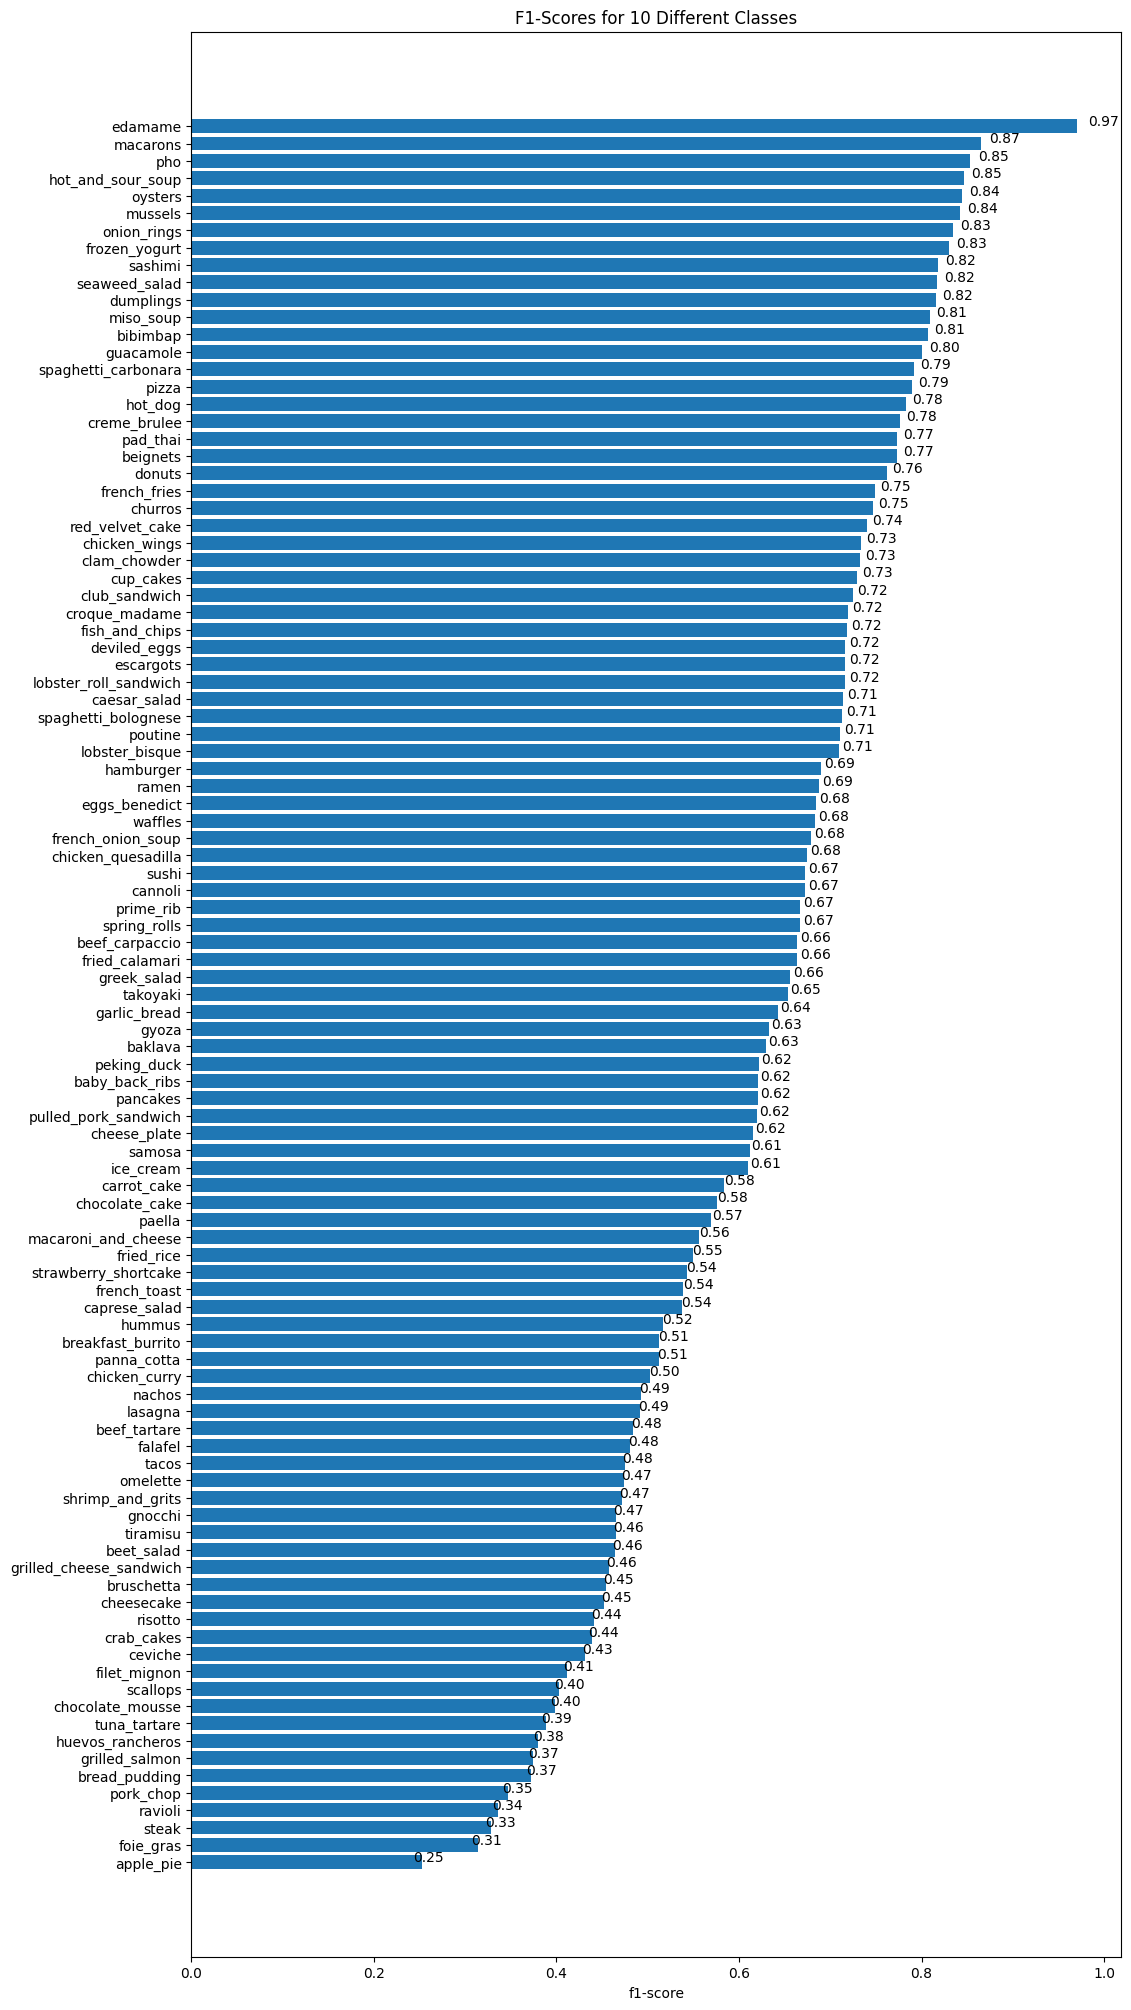

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 25))
scores = ax.barh(range(len(f1_scores)), f1_scores["F1 Score"].values)
ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(list(f1_scores["Class Name"]))
ax.set_xlabel("f1-score")
ax.set_title("F1-Scores for 10 Different Classes")
ax.invert_yaxis(); # reverse the order

def autolabel(rects): # Modified version of: https://matplotlib.org/examples/api/barchart_demo.html
  """
  Attach a text label above each bar displaying its height (it's value).
  """
  for rect in rects:
    width = rect.get_width()
    ax.text(1.03*width, rect.get_y() + rect.get_height()/1.5,
            f"{width:.2f}",
            ha='center', va='bottom')

autolabel(scores)

In [17]:
def load_and_prep_image(filename, img_shape=224, scale=True):
  """
  Reads in an image from filename, turns it into a tensor and reshapes into
  (224, 224, 3).

  Parameters
  ----------
  filename (str): string filename of target image
  img_shape (int): size to resize target image to, default 224
  scale (bool): whether to scale pixel values to range(0, 1), default True
  """
  # Read in the image
  img = tf.io.read_file(filename)
  # Decode it into a tensor
  img = tf.io.decode_image(img)
  # Resize the image
  img = tf.image.resize(img, [img_shape, img_shape])
  if scale:
    # Rescale the image (get all values between 0 and 1)
    return img/255.
  else:
    return img

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


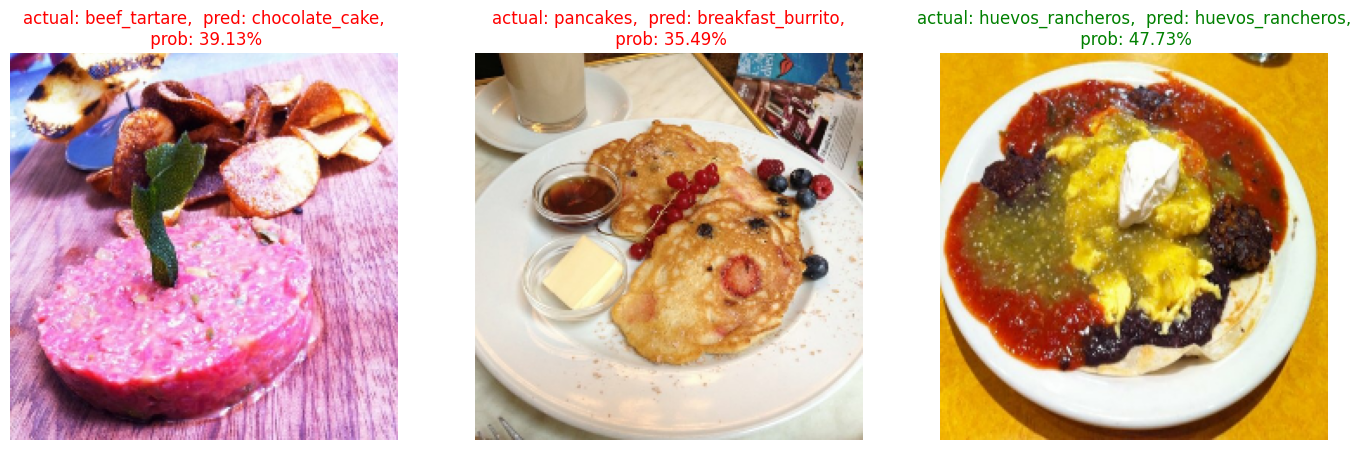

In [33]:
# Make preds on a series of random images
import os
import random

plt.figure(figsize=(17, 10))
for i in range(3):
  # Choose a random image from a random class
  class_name = random.choice(class_names)
  filename = random.choice(os.listdir(test_dir + "/" + class_name))
  filepath = test_dir + class_name + "/" + filename

  # Load the image and make predictions
  img = load_and_prep_image(filepath, scale=False) # don't scale images for EfficientNet predictions
  pred_prob = model_loaded.predict(tf.expand_dims(img, axis=0)) # model accepts tensors of shape [None, 224, 224, 3]
  pred_class = class_names[pred_prob.argmax()] # find the predicted class

  # Plot the image(s)
  plt.subplot(1, 3, i+1)
  # plt.imshow(img)
  plt.imshow(img.numpy().astype("uint8"))

  if class_name == pred_class: # Change the color of text based on whether prediction is right or wrong
    title_color = "g"
  else:
    title_color = "r"
  plt.title(f"actual: {class_name},  pred: {pred_class},\n prob: {pred_prob.max() * 100 :.2f}%", c=title_color)
  plt.axis(False);

In [26]:
filepaths = []
for i in test_data_10_percent.list_files("101_food_classes_10_percent/test/*/*.jpg",
                                     shuffle=False):
  filepaths.append(i.numpy())
filepaths[:10]

[b'101_food_classes_10_percent/test/apple_pie/1011328.jpg',
 b'101_food_classes_10_percent/test/apple_pie/101251.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1034399.jpg',
 b'101_food_classes_10_percent/test/apple_pie/103801.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1038694.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1047447.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1068632.jpg',
 b'101_food_classes_10_percent/test/apple_pie/110043.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1106961.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1113017.jpg']

In [29]:
pred_df = pd.DataFrame({'img_path':filepaths,
                        'y_true':y_true,
                        'y_pred':pred_classes,
                        'confidence':pred_probs.max(axis=1),
                        'y_true_classname':[class_names[i] for i in y_true],
                        'y_pred_classname':[class_names[i] for i in pred_classes]})

pred_df.head()

,img_path,y_true,y_pred,confidence,y_true_classname,y_pred_classname
0,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.344051,apple_pie,apple_pie
1,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.917568,apple_pie,apple_pie
2,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.435427,apple_pie,apple_pie
3,b'101_food_classes_10_percent/test/apple_pie/1...,0,8,0.293876,apple_pie,bread_pudding
4,b'101_food_classes_10_percent/test/apple_pie/1...,0,8,0.693075,apple_pie,bread_pudding


In [30]:
pred_df['pred_correct'] = pred_df['y_pred'] == pred_df['y_true']

In [31]:
pred_df.head()

,img_path,y_true,y_pred,confidence,y_true_classname,y_pred_classname,pred_correct
0,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.344051,apple_pie,apple_pie,True
1,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.917568,apple_pie,apple_pie,True
2,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.435427,apple_pie,apple_pie,True
3,b'101_food_classes_10_percent/test/apple_pie/1...,0,8,0.293876,apple_pie,bread_pudding,False
4,b'101_food_classes_10_percent/test/apple_pie/1...,0,8,0.693075,apple_pie,bread_pudding,False


In [32]:
top_100_wrong = pred_df[pred_df['pred_correct'] == False].sort_values('confidence',ascending=False)[:100]
top_100_wrong

,img_path,y_true,y_pred,confidence,y_true_classname,y_pred_classname,pred_correct
10847,b'101_food_classes_10_percent/test/fried_calam...,43,68,0.997132,fried_calamari,onion_rings,False
23797,b'101_food_classes_10_percent/test/sushi/16593...,95,86,0.996786,sushi,sashimi,False
15177,b'101_food_classes_10_percent/test/lobster_bis...,60,92,0.994531,lobster_bisque,spring_rolls,False
18001,b'101_food_classes_10_percent/test/pancakes/10...,72,67,0.993670,pancakes,omelette,False
10013,b'101_food_classes_10_percent/test/french_frie...,40,43,0.993016,french_fries,fried_calamari,False
...,...,...,...,...,...,...,...
11041,b'101_food_classes_10_percent/test/fried_rice/...,44,51,0.940701,fried_rice,guacamole,False
10947,b'101_food_classes_10_percent/test/fried_calam...,43,68,0.940288,fried_calamari,onion_rings,False
25166,b'101_food_classes_10_percent/test/waffles/335...,100,42,0.939912,waffles,french_toast,False
2654,b'101_food_classes_10_percent/test/bruschetta/...,10,76,0.939559,bruschetta,pizza,False


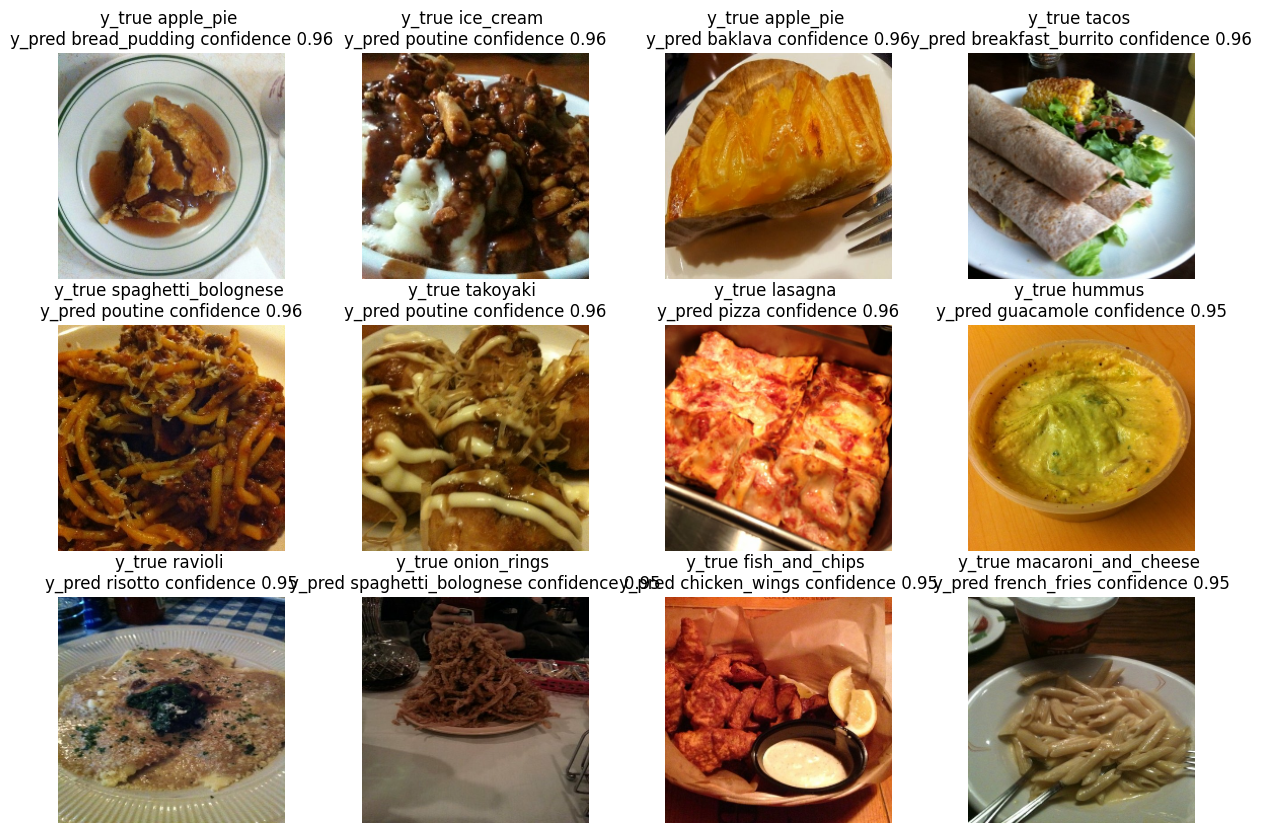

In [44]:
images_to_view = 12
start_idx = 56
plt.figure(figsize=(15, 10))
for i,row in enumerate(top_100_wrong[start_idx:start_idx+images_to_view].itertuples()):
  plt.subplot(3,4,i+1)
  img = load_and_prep_image(row[1],scale=True)
  _,_,_,_,confidence,y_true,y_pred,_ = row
  plt.title(f"y_true {y_true} \ny_pred {y_pred} confidence {confidence:.2f}")
  plt.imshow(img)
  plt.axis(False)


In [45]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/custom_food_images.zip

unzip_data("custom_food_images.zip")

--2026-09-17 03:36:53--  https://storage.googleapis.com/ztm_tf_course/food_vision/custom_food_images.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 34.153.2.27, 34.3.0.27, 34.144.171.27, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|34.153.2.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13192985 (13M) [application/zip]
Saving to: ‘custom_food_images.zip’

custom_food_images. 100%[===================>]  12.58M  47.2MB/s    in 0.3s    

2026-09-17 03:36:54 (47.2 MB/s) - ‘custom_food_images.zip’ saved [13192985/13192985]



In [46]:
walk_through_dir('custom_food_images')

There are 0 directories and 6 images in 'custom_food_images'.


In [49]:
custom_food_images = ['custom_food_images/' + img for img in os.listdir('custom_food_images')]
custom_food_images

['custom_food_images/chicken_wings.jpeg',
 'custom_food_images/ramen.jpeg',
 'custom_food_images/sushi.jpeg',
 'custom_food_images/hamburger.jpeg',
 'custom_food_images/steak.jpeg',
 'custom_food_images/pizza-dad.jpeg']

tf.Tensor(
[[[ 37.947384  26.947386  34.947384]
  [ 45.525192  34.525192  42.525192]
  [ 47.        34.        43.      ]
  ...
  [ 95.63348   97.92885  101.09361 ]
  [ 94.73375   95.73375   98.08196 ]
  [ 97.6186    94.6186   101.6186  ]]

 [[ 38.703762  28.703764  36.703762]
  [ 48.750637  38.750637  46.750637]
  [ 46.396366  33.396366  42.396366]
  ...
  [103.63829  110.63829  118.63829 ]
  [110.376915 110.376915 122.17213 ]
  [111.14446  108.14446  116.099815]]

 [[ 37.714287  30.714287  37.714287]
  [ 46.        39.        46.      ]
  [ 47.642857  35.357143  44.      ]
  ...
  [125.13747  121.2772   127.68062 ]
  [131.7344   131.921    139.56462 ]
  [131.12947  130.00925  128.24557 ]]

 ...

 [[ 25.623465  28.623465  59.623466]
  [ 29.571428  32.571426  63.571426]
  [ 26.384068  29.384068  60.384068]
  ...
  [ 56.207573  47.457104  51.25464 ]
  [ 47.170315  34.170315  43.170315]
  [ 44.272217  31.272217  40.272217]]

 [[ 22.263376  25.263376  56.263374]
  [ 23.736626  26.736626  

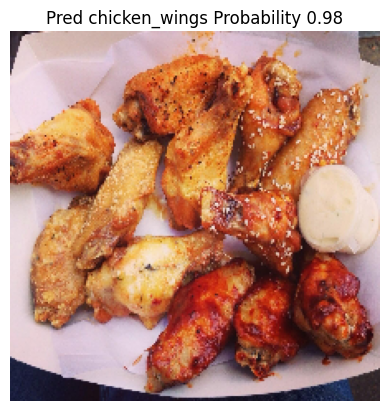

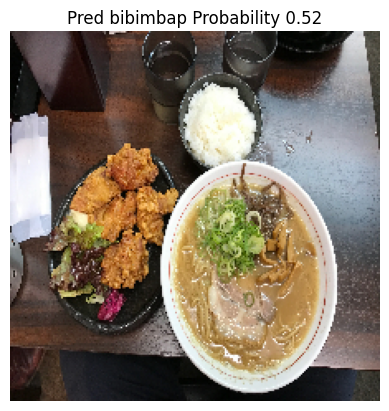

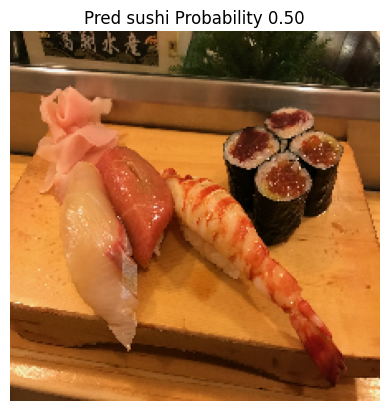

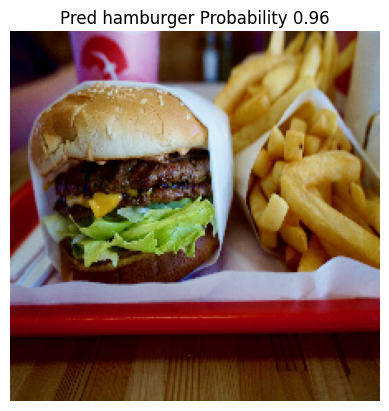

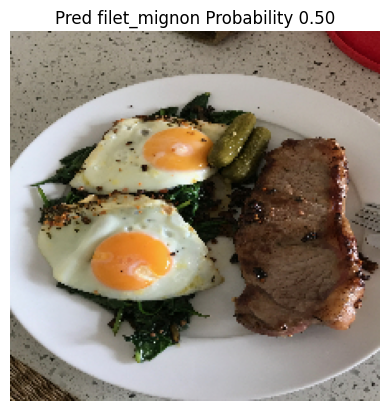

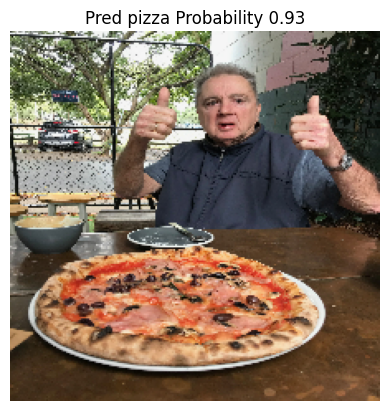

In [55]:
for img_file in custom_food_images:
  img = load_and_prep_image(img_file,scale=False)
  print(img)
  pred_prob = model_loaded.predict(tf.expand_dims(img,axis=0))
  pred_class = class_names[pred_prob.argmax()]
  plt.figure()
  plt.imshow(img.numpy().astype('uint8'))
  plt.title(f'Pred {pred_class} Probability {pred_prob.max():.2f}')
  plt.axis(False)

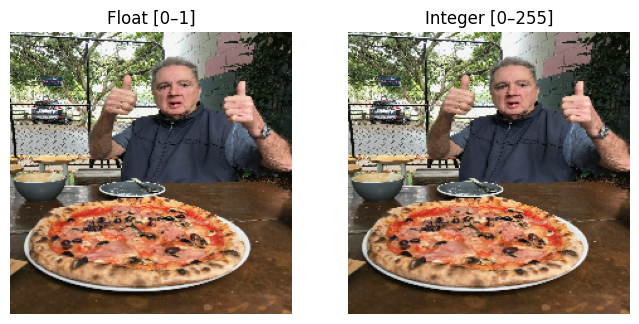

In [58]:
import tensorflow as tf
import matplotlib.pyplot as plt

img = load_and_prep_image('custom_food_images/pizza-dad.jpeg',scale=False)

# Case 1: Float image normalized to [0,1]
img_float = img / 255.0

# Case 2: Integer image in [0,255]
img_int = tf.cast(img, tf.uint8)

# Plot side by side
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_float.numpy())   # expects floats in [0,1]
plt.title("Float [0–1]")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_int.numpy())     # expects ints in [0–255]
plt.title("Integer [0–255]")
plt.axis("off")

plt.show()
